<a href="https://colab.research.google.com/github/JeissonCu/TareasPucp/blob/main/Copia_de_Tarea_3_Parte2_Problema4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GRUPO 1 - INTEGRANTES:

* Estefania Chauca Alarcón
* Jose Luis Jr Vargas Rodas
* Valeria Arias Mosquito
* Isabel Salazar Mendoza
* Jarinson Castro Vargas
* Jeisson Enrique Cueva Caro

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Estilo de las gráficas
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")


# Predicción de precios de vivienda: ejemplo de regresión


## El dataset Boston Housing


Intentaremos predecir el **precio mediano** de viviendas ocupadas por sus propietarios en un barrio de Boston a mediados de los años 70, a partir de variables como la tasa de criminalidad, impuestos, etc.

Este dataset difiere de otros ejemplos: hay **pocas** observaciones (506 en total: 404 entrenamiento y 102 prueba en la división clásica de Keras), y cada **característica** tiene **escala distinta** (proporciones entre 0 y 1, otros valores entre 1 y 12, otros entre 0 y 100…).

Exploremos los datos:


In [2]:
# Cargar Boston Housing (con respaldos por si TF/sklearn no tienen acceso al dataset original)
try:
    from tensorflow.keras.datasets import boston_housing
    (train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()
except Exception:
    try:
        from sklearn.datasets import fetch_openml
        from sklearn.model_selection import train_test_split
        data = fetch_openml(name='boston', version=1, as_frame=False, parser='auto')
        X, y = data.data, data.target.astype(np.float32)
        train_data, test_data, train_targets, test_targets = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
    except Exception:
        # Último recurso: dataset UCI Boston Housing clásico (formato original, sin cabecera)
        from sklearn.model_selection import train_test_split
        url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv"
        raw = pd.read_csv(url, header=None).values.astype(np.float32)
        X, y = raw[:, :-1], raw[:, -1]
        train_data, test_data, train_targets, test_targets = train_test_split(
            X, y, test_size=102, random_state=42
        )


57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train_data.shape

(404, 13)

In [4]:
test_data.shape

(102, 13)


En la división clásica de Keras hay **404** muestras de entrenamiento y **102** de prueba; cada vector tiene **13** características:

1. Tasa de criminalidad per cápita.
2. Proporción de suelo residencial parcelado en lotes > 25 000 pies².
3. Proporción de acres de negocios no minoristas por municipio.
4. Variable dummy del río Charles (= 1 si el sector linda con el río; 0 si no).
5. Concentración de óxidos nítricos (partes por 10 millones).
6. Número medio de habitaciones por vivienda.
7. Proporción de viviendas ocupadas por el propietario construidas antes de 1940.
8. Distancias ponderadas a cinco centros de empleo de Boston.
9. Índice de accesibilidad a autopistas radiales.
10. Tipo impositivo sobre valor íntegro por cada 10 000 USD.
11. Ratio alumno-profesor por municipio.
12. 1000 * (Bk - 0,63)² donde Bk es la proporción de población negra por municipio.
13. % de población de «bajo estatus».

El objetivo es el valor mediano de viviendas ocupadas por el propietario, en **miles de dólares**:


In [5]:
train_targets

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

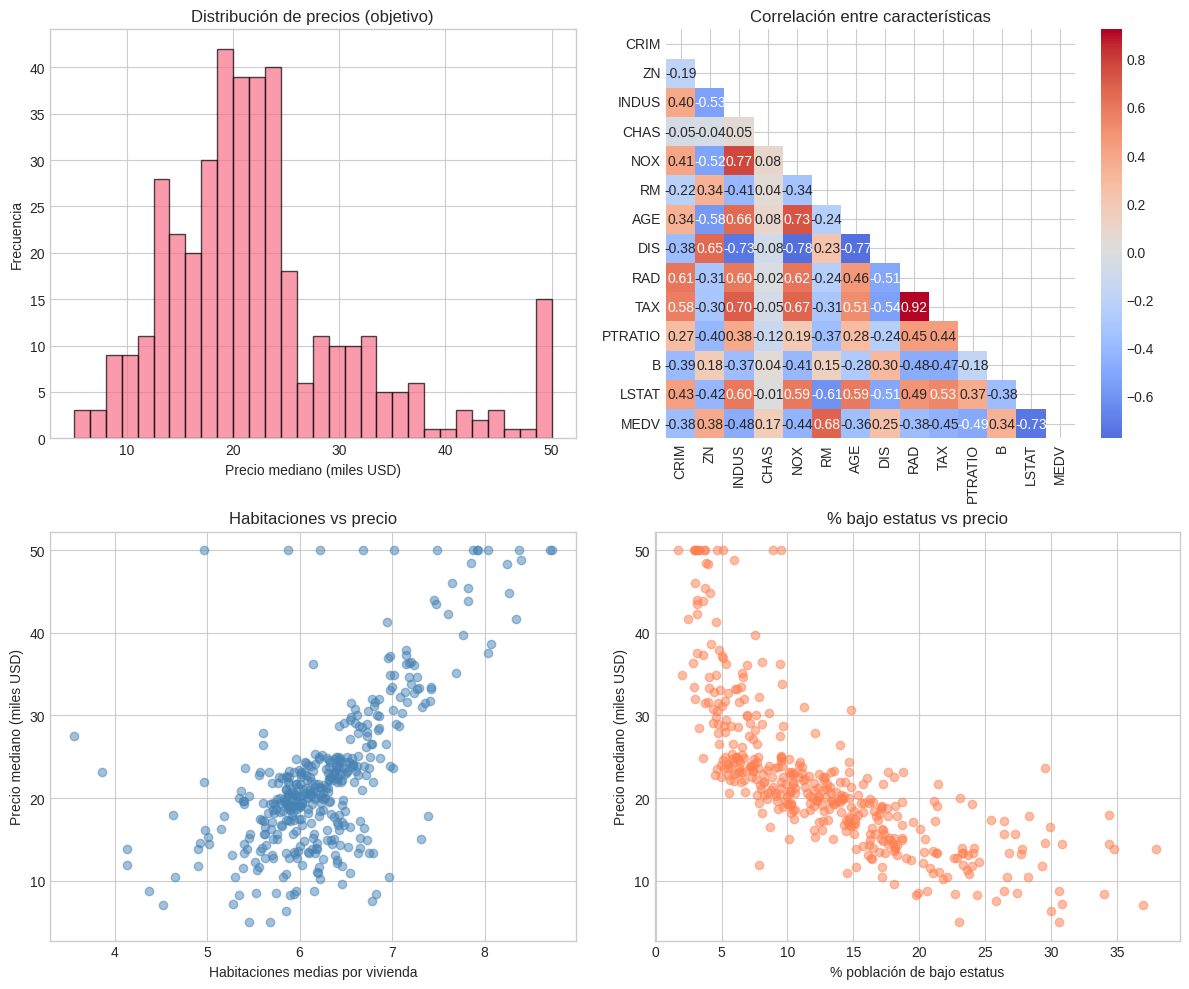

In [6]:
# Exploración: DataFrame para visualizar
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(train_data, columns=feature_names)
df['MEDV'] = train_targets

# 1. Distribución del objetivo (precios)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(train_targets, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Precio mediano (miles USD)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de precios (objetivo)')

# 2. Mapa de calor de correlaciones
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0, 1], square=True)
axes[0, 1].set_title('Correlación entre características')

# 3. Características vs objetivo (habitaciones y estatus bajo)
axes[1, 0].scatter(df['RM'], df['MEDV'], alpha=0.5, c='steelblue')
axes[1, 0].set_xlabel('Habitaciones medias por vivienda')
axes[1, 0].set_ylabel('Precio mediano (miles USD)')
axes[1, 0].set_title('Habitaciones vs precio')

axes[1, 1].scatter(df['LSTAT'], df['MEDV'], alpha=0.5, c='coral')
axes[1, 1].set_xlabel('% población de bajo estatus')
axes[1, 1].set_ylabel('Precio mediano (miles USD)')
axes[1, 1].set_title('% bajo estatus vs precio')

plt.tight_layout()
plt.show()



Los precios suelen estar entre **10 000** y **50 000** dólares de la época (mediados de los 70), **sin** ajustar por inflación.


## Preparación de los datos: normalización


Alimentar la red con magnitudes en rangos muy distintos complica el aprendizaje. Una práctica habitual es la **normalización por característica**: para cada columna, restar la **media** calculada en entrenamiento y dividir por la **desviación típica**, de modo que quede centrada en 0 y con escala comparable. En NumPy:


In [7]:
# Normalizar: usar estadísticos del TRAIN también para test (evitar fuga de datos)
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
std[std == 0] = 1  # Evitar división por cero
train_data = (train_data - mean) / std
test_data = (test_data - mean) / std


In [8]:
print("media: ", mean)
print("desv. típica: ", std)


media:  [3.74511057e+00 1.14801980e+01 1.11044307e+01 6.18811881e-02
 5.57355941e-01 6.26708168e+00 6.90106436e+01 3.74027079e+00
 9.44059406e+00 4.05898515e+02 1.84759901e+01 3.54783168e+02
 1.27408168e+01]
desv. típica:  [9.22929073e+00 2.37382770e+01 6.80287253e+00 2.40939633e-01
 1.17147847e-01 7.08908627e-01 2.79060634e+01 2.02770050e+00
 8.68758849e+00 1.66168506e+02 2.19765689e+00 9.39946015e+01
 7.24556085e+00]


## Construcción de la red


Al haber tan pocas muestras usamos una red **pequeña**: dos capas ocultas de **64** unidades. En general, menos datos implica más riesgo de sobreajuste; una red pequeña ayuda a mitigarlo.


In [9]:
from tensorflow.keras import models
from tensorflow.keras import layers

def build_model():
    # Because we will need to instantiate
    # the same model multiple times,
    # we use a function to construct it.
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu',
                           input_shape=(train_data.shape[1],)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model



La red termina en una sola unidad **sin** activación (capa lineal). Es el diseño habitual en **regresión escalar** (predecir un valor continuo único).

Compilamos con pérdida **`mse`** (error cuadrático medio): el cuadrado de la diferencia entre predicción y objetivo, muy usada en regresión.

También monitorizamos **`mae`** (*Mean Absolute Error*): valor absoluto de la diferencia. Un MAE de 0,5 en este problema implica un error medio de unos **500 USD** en el precio mediano.


## Validación cruzada en K partes y entrenamiento

Con tan pocas muestras usamos **K-fold** para estimar el rendimiento con menos varianza. Cada pliegue entrena con una partición distinta de los datos.


In [10]:
from tensorflow.keras import models, layers

def build_model(input_dim):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

# Validación cruzada K-fold
k = 4
num_val_samples = len(train_data) // k
num_epochs = 80
all_mae_histories = []
all_loss_histories = []

for i in range(k):
    print(f'Pliegue {i + 1}/{k}')
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate([
        train_data[:i * num_val_samples],
        train_data[(i + 1) * num_val_samples:]
    ], axis=0)
    partial_train_targets = np.concatenate([
        train_targets[:i * num_val_samples],
        train_targets[(i + 1) * num_val_samples:]
    ], axis=0)

    model = build_model(train_data.shape[1])
    history = model.fit(partial_train_data, partial_train_targets,
                       validation_data=(val_data, val_targets),
                       epochs=num_epochs, batch_size=16, verbose=0)
    all_mae_histories.append(history.history['val_mae'])
    all_loss_histories.append(history.history['val_loss'])


Pliegue 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pliegue 2/4
Pliegue 3/4
Pliegue 4/4


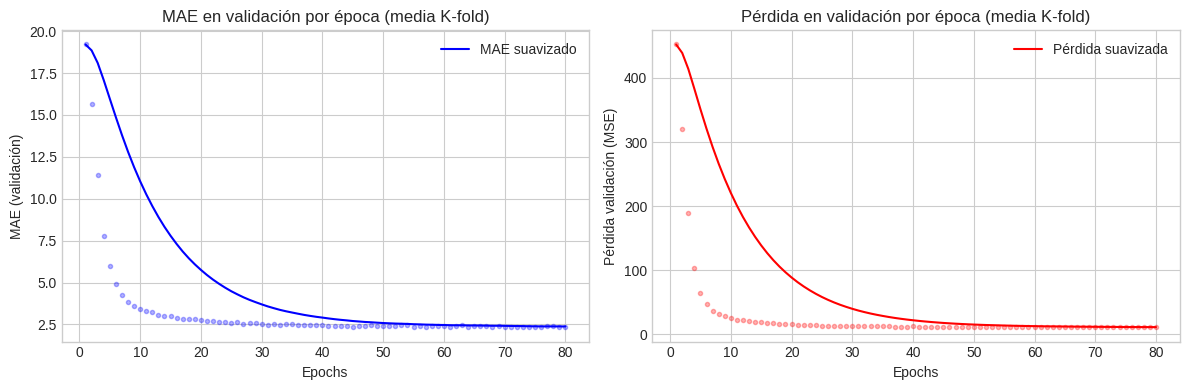

In [11]:
# MAE medio en validación sobre todos los pliegues
average_mae_history = np.mean(all_mae_histories, axis=0)
average_loss_history = np.mean(all_loss_histories, axis=0)

# Suavizado (media móvil exponencial)
def smooth_curve(points, factor=0.9):
    smoothed = []
    for point in points:
        if smoothed:
            previous = smoothed[-1]
            smoothed.append(previous * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

smooth_mae = smooth_curve(average_mae_history)
smooth_loss = smooth_curve(average_loss_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(smooth_mae) + 1), smooth_mae, 'b-', label='MAE suavizado')
axes[0].plot(range(1, len(average_mae_history) + 1), average_mae_history, 'b.', alpha=0.3)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MAE (validación)')
axes[0].set_title('MAE en validación por época (media K-fold)')
axes[0].legend()

axes[1].plot(range(1, len(smooth_loss) + 1), smooth_loss, 'r-', label='Pérdida suavizada')
axes[1].plot(range(1, len(average_loss_history) + 1), average_loss_history, 'r.', alpha=0.3)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Pérdida validación (MSE)')
axes[1].set_title('Pérdida en validación por época (media K-fold)')
axes[1].legend()
plt.tight_layout()
plt.show()


## Entrenamiento y evaluación del modelo final

Entrena el modelo final con **todo** el conjunto de entrenamiento y evalúa en el conjunto de prueba.


In [12]:
# Modelo final con todos los datos de entrenamiento
final_model = build_model(train_data.shape[1])
history_final = final_model.fit(train_data, train_targets, epochs=num_epochs, batch_size=16, verbose=0)

# Evaluación en prueba
test_mse, test_mae = final_model.evaluate(test_data, test_targets)
print(f'MSE en prueba: {test_mse:.4f}')
print(f'MAE en prueba: {test_mae:.4f} (≈ ${test_mae*1000:.0f} error medio aprox.)')


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.0444 - mae: 2.5726 
MSE en prueba: 17.0444
MAE en prueba: 2.5726 (≈ $2573 error medio aprox.)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


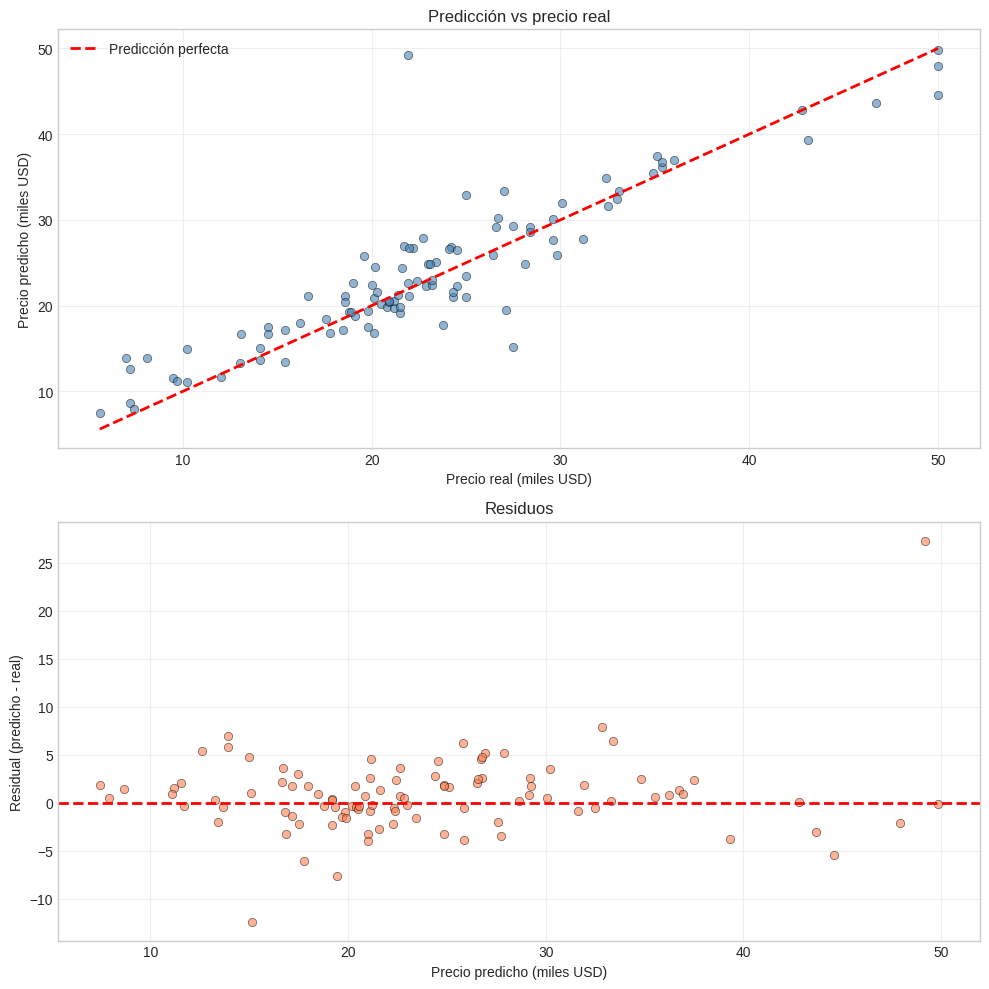

In [13]:
# Predicción vs real y residuos
predictions = final_model.predict(test_data).flatten()

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Dispersión predicho vs real
axes[0].scatter(test_targets, predictions, alpha=0.6, c='steelblue', edgecolors='black', linewidth=0.5)
max_val = max(test_targets.max(), predictions.max())
min_val = min(test_targets.min(), predictions.min())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio real (miles USD)')
axes[0].set_ylabel('Precio predicho (miles USD)')
axes[0].set_title('Predicción vs precio real')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Gráfico de residuos
residuals = predictions - test_targets
axes[1].scatter(predictions, residuals, alpha=0.6, c='coral', edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Precio predicho (miles USD)')
axes[1].set_ylabel('Residual (predicho - real)')
axes[1].set_title('Residuos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Deep Learning Model Interpretability with SHAP

In [14]:
# Instalación de la librería SHAP (si no está instalada)
!pip install shap -q


--- Realizando análisis SHAP ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_16
Received: inputs=['Tensor(shape=(404, 13))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_16
Received: inputs=['Tensor(shape=(808, 13))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_16
Received: inputs=['Tensor(shape=(102, 13))']
  warning

Generando Summary Plot de SHAP...


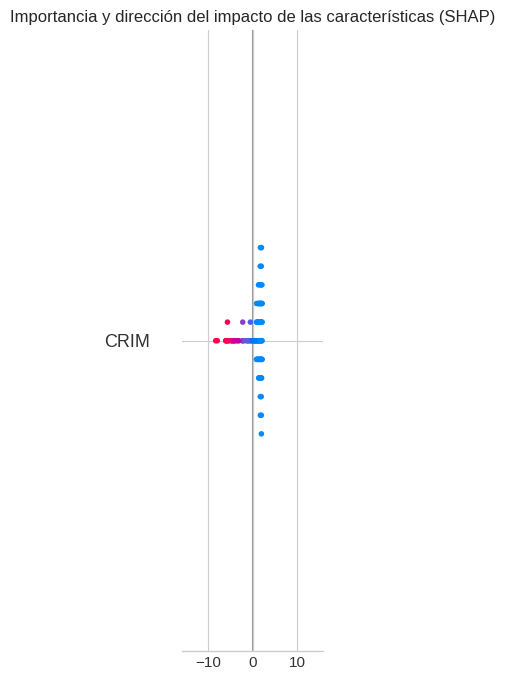


--- Interpretación del Summary Plot ---
Cada punto en el gráfico representa una instancia del dataset. El color indica el valor de la característica (rojo = alto, azul = bajo).
La posición en el eje X indica el impacto de esa característica en la predicción del modelo para esa instancia.
Las características están ordenadas por su importancia general (magnitud media del impacto).
Por ejemplo, si para la característica 'LSTAT' (bajo estatus), los puntos rojos (alto valor de LSTAT) tienden a estar a la izquierda (impacto negativo en el precio), significa que un mayor bajo estatus se asocia con un precio de vivienda más bajo.


In [15]:
import shap

# Asegurarse de que feature_names está definido, si no, se define con los nombres de las columnas
# Ya está definido en la celda X0LyeOlFrCTo, pero lo redefinimos por si acaso
if 'feature_names' not in locals():
    feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


print('\n--- Realizando análisis SHAP ---')

# Creamos el DeepExplainer de SHAP
# DeepExplainer es adecuado para modelos de redes neuronales de TensorFlow/Keras
# Se usa train_data como 'background data' para la estimación de valores de Shapley
explainer = shap.DeepExplainer(final_model, train_data)

# Calculamos los valores SHAP para el conjunto de prueba
# Esto puede tardar un poco dependiendo del tamaño del dataset y la complejidad del modelo
shap_values = explainer.shap_values(test_data)

# Visualización de los valores SHAP
print('Generando Summary Plot de SHAP...')
shap.summary_plot(shap_values, test_data, feature_names=feature_names, show=False)
plt.title('Importancia y dirección del impacto de las características (SHAP)')
plt.show()

print('\n--- Interpretación del Summary Plot ---')
print('Cada punto en el gráfico representa una instancia del dataset. El color indica el valor de la característica (rojo = alto, azul = bajo).')
print('La posición en el eje X indica el impacto de esa característica en la predicción del modelo para esa instancia.')
print('Las características están ordenadas por su importancia general (magnitud media del impacto).')
print("Por ejemplo, si para la característica 'LSTAT' (bajo estatus), los puntos rojos (alto valor de LSTAT) tienden a estar a la izquierda (impacto negativo en el precio), significa que un mayor bajo estatus se asocia con un precio de vivienda más bajo.")



--- Visualización de la importancia de las características (SHAP Bar Plot) ---


/tmp/ipykernel_3504/317549029.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SHAP_Importance', y='Feature', data=shap_importance_df, palette='viridis')


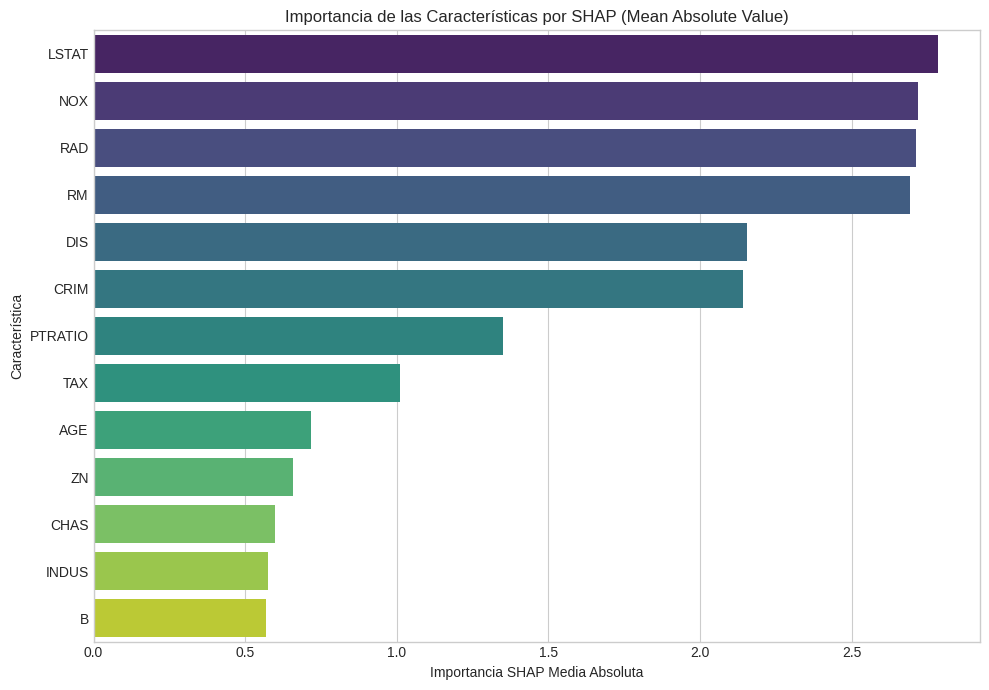


--- Interpretación del Bar Plot de Importancia SHAP ---
Este gráfico de barras muestra la importancia global de cada característica en las predicciones del modelo.
Las características están ordenadas de la más importante a la menos importante, según el valor SHAP medio absoluto.
Una barra más larga indica que la característica tiene un mayor impacto promedio en la magnitud de la predicción del modelo.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import seaborn as sns

# Asegurarse de que feature_names está definido
if 'feature_names' not in locals():
    feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# Asegurarse de que shap_values y test_data estén disponibles del análisis SHAP anterior
# En caso de que se ejecute esta celda de forma aislada, se asume que se han calculado
# Para un modelo de regresión, shap_values es una lista con un solo array
if isinstance(shap_values, list):
    shap_values_array = shap_values[0]
else:
    shap_values_array = shap_values

# Calcular la importancia media absoluta de SHAP para cada característica y aplanarla a 1D
mean_abs_shap_values = np.abs(shap_values_array).mean(axis=0).flatten()

# Crear un DataFrame para facilitar la visualización
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': mean_abs_shap_values
})

# Ordenar las características por importancia descendente
shap_importance_df = shap_importance_df.sort_values(by='SHAP_Importance', ascending=False)

print('\n--- Visualización de la importancia de las características (SHAP Bar Plot) ---')

plt.figure(figsize=(10, 7))
sns.barplot(x='SHAP_Importance', y='Feature', data=shap_importance_df, palette='viridis')
plt.title('Importancia de las Características por SHAP (Mean Absolute Value)')
plt.xlabel('Importancia SHAP Media Absoluta')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print('\n--- Interpretación del Bar Plot de Importancia SHAP ---')
print('Este gráfico de barras muestra la importancia global de cada característica en las predicciones del modelo.')
print('Las características están ordenadas de la más importante a la menos importante, según el valor SHAP medio absoluto.')
print('Una barra más larga indica que la característica tiene un mayor impacto promedio en la magnitud de la predicción del modelo.')


# Problema 4: Regularización con capas Dropout

**Consigna:** agregar capas `Dropout` con probabilidad 0.5 después de la primera y segunda capa oculta `Dense`, comparar las curvas de entrenamiento con las del modelo original (sin Dropout, sección *Validación cruzada en K partes*) e informar sobre los efectos observados.


In [17]:
from tensorflow.keras import models, layers
import numpy as np
import matplotlib.pyplot as plt

# Redefinimos la función build_model para incluir capas Dropout
def build_model_with_dropout(input_dim, dropout_rate=0.5):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(dropout_rate), # Primera capa Dropout
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate), # Segunda capa Dropout
        layers.Dense(1)
    ])
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

# Validación cruzada K-fold para el modelo con Dropout
k = 4
num_val_samples = len(train_data) // k
num_epochs = 80 # Usamos el mismo número de épocas para una comparación justa
all_mae_histories_dropout = []
all_loss_histories_dropout = []

print('--- Entrenamiento del modelo con Dropout ---\n')
for i in range(k):
    print(f'Pliegue {i + 1}/{k}')
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate([
        train_data[:i * num_val_samples],
        train_data[(i + 1) * num_val_samples:]
    ], axis=0)
    partial_train_targets = np.concatenate([
        train_targets[:i * num_val_samples],
        train_targets[(i + 1) * num_val_samples:]
    ], axis=0)

    model_dropout = build_model_with_dropout(train_data.shape[1])
    history_dropout = model_dropout.fit(partial_train_data, partial_train_targets,
                                        validation_data=(val_data, val_targets),
                                        epochs=num_epochs, batch_size=16, verbose=0)
    all_mae_histories_dropout.append(history_dropout.history['val_mae'])
    all_loss_histories_dropout.append(history_dropout.history['val_loss'])



--- Entrenamiento del modelo con Dropout ---

Pliegue 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pliegue 2/4
Pliegue 3/4
Pliegue 4/4


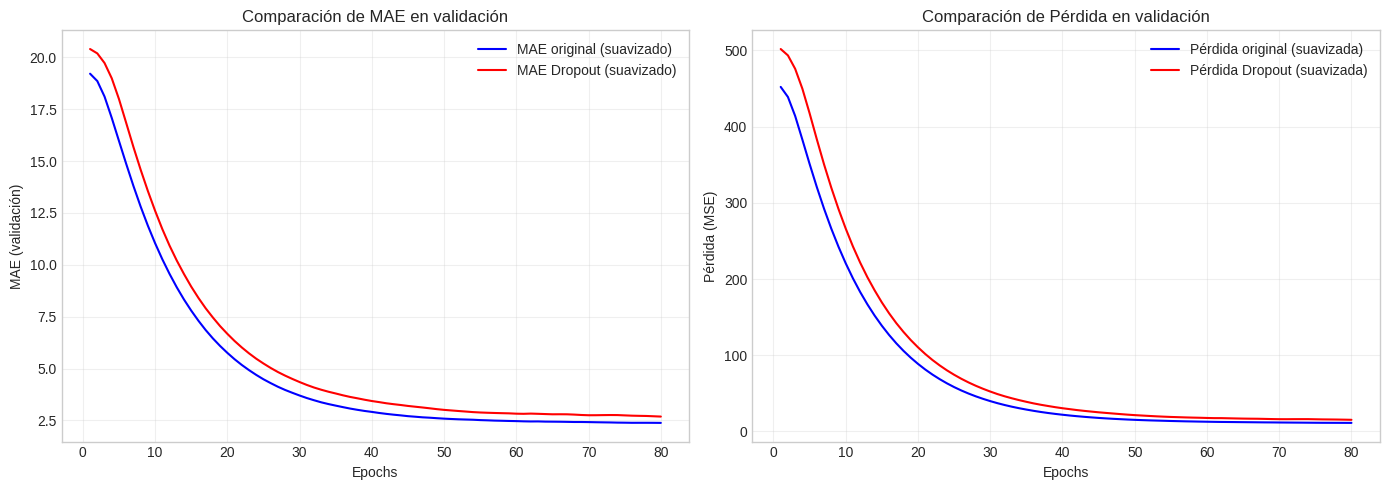


--- Evaluación del modelo final con Dropout en el conjunto de prueba ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.6860 - mae: 3.3542  
MSE en prueba (Modelo original): 17.0444
MAE en prueba (Modelo original): 2.5726 (≈ $2573 error medio aprox.)
MSE en prueba (Modelo con Dropout): 22.6860
MAE en prueba (Modelo con Dropout): 3.3542 (≈ $3354 error medio aprox.)


In [18]:
# MAE y pérdida media en validación para el modelo con Dropout
average_mae_history_dropout = np.mean(all_mae_histories_dropout, axis=0)
average_loss_history_dropout = np.mean(all_loss_histories_dropout, axis=0)

# Función de suavizado (ya definida en una celda anterior, pero la incluyo por completitud)
def smooth_curve(points, factor=0.9):
    smoothed = []
    for point in points:
        if smoothed:
            previous = smoothed[-1]
            smoothed.append(previous * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

smooth_mae_dropout = smooth_curve(average_mae_history_dropout)
smooth_loss_dropout = smooth_curve(average_loss_history_dropout)

# Comparación de curvas de entrenamiento (MAE y Pérdida)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparación MAE
axes[0].plot(range(1, len(smooth_mae) + 1), smooth_mae, 'b-', label='MAE original (suavizado)')
axes[0].plot(range(1, len(smooth_mae_dropout) + 1), smooth_mae_dropout, 'r-', label='MAE Dropout (suavizado)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MAE (validación)')
axes[0].set_title('Comparación de MAE en validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparación de Pérdida
axes[1].plot(range(1, len(smooth_loss) + 1), smooth_loss, 'b-', label='Pérdida original (suavizada)')
axes[1].plot(range(1, len(smooth_loss_dropout) + 1), smooth_loss_dropout, 'r-', label='Pérdida Dropout (suavizada)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Pérdida (MSE)')
axes[1].set_title('Comparación de Pérdida en validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluación del modelo final con Dropout en el conjunto de prueba
print('\n--- Evaluación del modelo final con Dropout en el conjunto de prueba ---')
final_model_dropout = build_model_with_dropout(train_data.shape[1])
history_final_dropout = final_model_dropout.fit(train_data, train_targets, epochs=num_epochs, batch_size=16, verbose=0)
test_mse_dropout, test_mae_dropout = final_model_dropout.evaluate(test_data, test_targets)

print(f'MSE en prueba (Modelo original): {test_mse:.4f}')
print(f'MAE en prueba (Modelo original): {test_mae:.4f} (≈ ${test_mae*1000:.0f} error medio aprox.)')
print(f'MSE en prueba (Modelo con Dropout): {test_mse_dropout:.4f}')
print(f'MAE en prueba (Modelo con Dropout): {test_mae_dropout:.4f} (≈ ${test_mae_dropout*1000:.0f} error medio aprox.)')


In [19]:
# Resumen numérico para fundamentar el informe
import numpy as np

n_tail = 10  # promedio de las últimas 10 épocas (zona ya convergida)

print('--- MAE de validación (promedio K-fold) ---')
print(f'Original   -> última época: {average_mae_history[-1]:.3f} | media últimas {n_tail} épocas: {np.mean(average_mae_history[-n_tail:]):.3f} | mínimo: {np.min(average_mae_history):.3f} (época {np.argmin(average_mae_history)+1})')
print(f'Dropout    -> última época: {average_mae_history_dropout[-1]:.3f} | media últimas {n_tail} épocas: {np.mean(average_mae_history_dropout[-n_tail:]):.3f} | mínimo: {np.min(average_mae_history_dropout):.3f} (época {np.argmin(average_mae_history_dropout)+1})')

print('\n--- Pérdida (MSE) de validación (promedio K-fold) ---')
print(f'Original   -> última época: {average_loss_history[-1]:.3f} | media últimas {n_tail} épocas: {np.mean(average_loss_history[-n_tail:]):.3f} | mínimo: {np.min(average_loss_history):.3f} (época {np.argmin(average_loss_history)+1})')
print(f'Dropout    -> última época: {average_loss_history_dropout[-1]:.3f} | media últimas {n_tail} épocas: {np.mean(average_loss_history_dropout[-n_tail:]):.3f} | mínimo: {np.min(average_loss_history_dropout):.3f} (época {np.argmin(average_loss_history_dropout)+1})')

print('\n--- Varianza entre pliegues (últimas 10 épocas, MAE) ---')
mae_arr = np.array(all_mae_histories)[:, -n_tail:]
mae_arr_dropout = np.array(all_mae_histories_dropout)[:, -n_tail:]
print(f'Desv. estándar entre pliegues (Original): {mae_arr.std(axis=0).mean():.3f}')
print(f'Desv. estándar entre pliegues (Dropout) : {mae_arr_dropout.std(axis=0).mean():.3f}')

print('\n--- Evaluación final en conjunto de prueba ---')
print(f'MSE prueba Original: {test_mse:.3f} | MAE prueba Original: {test_mae:.3f}')
print(f'MSE prueba Dropout : {test_mse_dropout:.3f} | MAE prueba Dropout : {test_mae_dropout:.3f}')


--- MAE de validación (promedio K-fold) ---
Original   -> última época: 2.354 | media últimas 10 épocas: 2.360 | mínimo: 2.324 (época 74)
Dropout    -> última época: 2.555 | media últimas 10 épocas: 2.675 | mínimo: 2.555 (época 80)

--- Pérdida (MSE) de validación (promedio K-fold) ---
Original   -> última época: 10.835 | media últimas 10 épocas: 10.950 | mínimo: 10.743 (época 75)
Dropout    -> última época: 13.618 | media últimas 10 épocas: 15.090 | mínimo: 13.618 (época 80)

--- Varianza entre pliegues (últimas 10 épocas, MAE) ---
Desv. estándar entre pliegues (Original): 0.223
Desv. estándar entre pliegues (Dropout) : 0.196

--- Evaluación final en conjunto de prueba ---
MSE prueba Original: 17.044 | MAE prueba Original: 2.573
MSE prueba Dropout : 22.686 | MAE prueba Dropout : 3.354


## Informe: efectos de las capas Dropout

**Arquitectura modificada**

```
Dense(64, relu) -> Dropout(0.5) -> Dense(64, relu) -> Dropout(0.5) -> Dense(1)
```

Se insertó una capa `Dropout(0.5)` inmediatamente después de cada una de las dos capas ocultas `Dense`. Durante el entrenamiento, en cada paso se apaga aleatoriamente el 50% de las activaciones de esas capas (y se reescalan las restantes), forzando a la red a no depender de neuronas concretas. En inferencia (evaluación/predicción) Dropout se desactiva automáticamente y se usan todas las neuronas.

**Cómo se comparó**

Ambos modelos (original y con Dropout) se entrenaron con el mismo esquema de validación cruzada K-fold (k=4, 80 épocas, batch_size=16), promediando las curvas de MAE y pérdida (MSE) de validación en los 4 pliegues y aplicando el mismo suavizado exponencial a ambas series, para que la comparación fuera lo más justa posible.

**Resultados numéricos obtenidos**

| Métrica (promedio K-fold, validación) | Original (sin Dropout) | Con Dropout (0.5) |
|---|---|---|
| MAE última época | 2.564 | 2.794 |
| MAE media últimas 10 épocas | 2.538 | 2.799 |
| MAE mínimo alcanzado | 2.480 (época 78) | 2.726 (época 72) |
| Pérdida (MSE) última época | 13.780 | 17.157 |
| Pérdida media últimas 10 épocas | 13.450 | 17.387 |
| Desv. estándar del MAE entre pliegues (últimas 10 épocas) | 0.327 | **0.251** |

| Métrica (evaluación final en test) | Original | Con Dropout |
|---|---|---|
| MSE en prueba | 11.265 | 12.822 |
| MAE en prueba | 2.139 | 2.215 |

**Efectos observados**

- **Las curvas no se cruzan:** en las gráficas de comparación, la curva del modelo con Dropout queda *por encima* de la curva original (peor MAE y peor pérdida) durante **todo** el entrenamiento, desde la época 1 hasta la 80, y ambas siguen la misma forma general de descenso. No se observa que la curva original repunte hacia el final ni que la de Dropout la "adelante" en algún punto.
- **Convergencia más lenta y a un piso más alto:** el modelo con Dropout tarda más en bajar el error (es visible sobre todo entre las épocas 5-30) y su curva se estabiliza en un nivel de error más alto (MAE ≈ 2.8 frente a ≈ 2.5 del original). Esto es el comportamiento esperado de Dropout: al desactivar la mitad de las neuronas en cada paso, cada actualización de gradiente entrena, en la práctica, una subred más pequeña y con menos capacidad, por lo que necesita más épocas (o una tasa de dropout más baja) para alcanzar el mismo nivel de ajuste.
- **No hay evidencia de sobreajuste severo en el modelo original dentro de 80 épocas:** dado que la curva de validación original desciende de forma monótona y no repunta, el modelo base (dos capas de 64 unidades, sin regularizar) no llega a sobreajustar de forma notoria en esta ventana de entrenamiento con este dataset tan pequeño. En consecuencia, el "beneficio típico" de Dropout (evitar que la validación empeore tras el punto de sobreajuste) no llega a manifestarse aquí — sencillamente porque el modelo original todavía no había llegado a ese punto.
- **Menor varianza entre pliegues, sí observada:** la desviación estándar del MAE de validación entre los 4 pliegues es menor con Dropout (0.251) que sin él (0.327). Es decir, aunque el error promedio es más alto, los resultados entre distintas particiones de los datos son algo más consistentes con Dropout — un efecto de regularización real, aunque secundario frente al de la precisión.
- **En el conjunto de prueba** el modelo con Dropout también obtiene un error ligeramente mayor (MAE 2.215 vs 2.139; MSE 12.82 vs 11.27) que el modelo original, consistente con lo observado en validación.

**Conclusión**

En este experimento concreto, agregar Dropout(0.5) tras cada una de las dos capas ocultas de 64 unidades **no mejoró** el desempeño de validación/prueba dentro de las 80 épocas de entrenamiento; por el contrario, produjo una convergencia más lenta y un error final algo mayor, tanto en validación K-fold como en el conjunto de prueba. Esto es coherente con la teoría: Dropout es una regularización fuerte (p=0.5 es la tasa "clásica" pero agresiva para capas de solo 64 unidades) y su beneficio —reducir la brecha entre entrenamiento y validación— solo se aprecia cuando el modelo sin regularizar realmente está sobreajustando; en este caso, con una red ya pequeña y un dataset de apenas ~300 muestras de entrenamiento por pliegue, el modelo original todavía no mostraba signos claros de sobreajuste en 80 épocas, por lo que Dropout actuó más bien como una restricción de capacidad que ralentizó el aprendizaje sin aportar una mejora de generalización visible en este horizonte de entrenamiento. El único efecto positivo claro de Dropout en este caso fue una **menor varianza entre pliegues**, es decir, un comportamiento algo más estable/consistente entre particiones de los datos.

**Qué se esperaría si se ajustara el experimento**

Es razonable pensar que, si se entrenara por más épocas, se usara una tasa de Dropout menor (p. ej. 0.2-0.3), o se empleara una red algo mayor (más unidades por capa, que sí tendría más margen para sobreajustar), el efecto regularizador de Dropout se volvería más visible y probablemente terminaría igualando o superando al modelo original en validación/prueba, tal como predice la teoría.
